# 05 — Synthesis: This Is Not the New Norm

This notebook brings together the findings from notebooks 02–04 into a single coherent argument. It is intended to be readable as a standalone document — a summary of the evidence and its implications that does not require familiarity with the preceding analysis.

The claim being challenged: that the UK's recent run of warm summers represents a *new norm* — a stable adjustment to a slightly warmer climate that we can plan around and adapt to.

The data says something different.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from pathlib import Path

PROCESSED = Path('../data/processed')
OUTPUTS   = Path('../outputs')

plt.style.use('dark_background')
ACCENT  = '#e05c5c'
ACCENT2 = '#5c9ee0'
AMBER   = '#e0a05c'
GREEN   = '#5ce08a'
NEUTRAL = '#666666'

BASELINE_START = 1961
BASELINE_END   = 1990

df = pd.read_csv(PROCESSED / 'climate_series.csv')

def get_series(variable, region, period, max_year=2025):
    return (
        df[
            (df['variable'] == variable) &
            (df['region']   == region)   &
            (df['period']   == period)   &
            (df['year']     <= max_year)
        ]
        .dropna(subset=['value'])
        .sort_values('year')
        .copy()
    )

tmean    = get_series('Tmean',    'UK', 'ann')
baseline = tmean[(tmean['year']>=BASELINE_START)&(tmean['year']<=BASELINE_END)]['value'].mean()

print(f'UK Tmean: {len(tmean)} years, {tmean["year"].min()}–{tmean["year"].max()}')
print(f'1961–1990 baseline: {baseline:.3f}°C')

UK Tmean: 142 years, 1884–2025
1961–1990 baseline: 8.315°C


## The Argument in Five Points

### 1. The warming rate has nearly tripled in the modern period

Across the full 141-year record, UK mean annual temperature has risen at approximately 0.12°C per decade. In the period from 1991 to 2025, the rate is 0.33°C per decade — nearly three times faster. This is not a step change followed by stability. The slope is steeper now than at any point in the instrumental record.

A new norm would show a period of change followed by flattening. The rolling trend analysis in notebook 02 shows the opposite: the slope has been rising since the 1980s and remains elevated. Every time window we fit to the data — including the most recent 15 years — shows a statistically significant positive warming trend. The slope has not flattened.

### 2. This is not a warmer summers story

All four seasons are warming, and in the recent period winter is warming *faster* than summer. The framing of climate change as a matter of warmer summers is not just incomplete — it misrepresents the nature and extent of what is happening. Every month of the year is warming. No region of the UK is exempt.

### 3. Variability is increasing alongside the mean

A genuine new norm would imply not just a higher mean but a similar degree of variability around it — different average, same predictability. Year-to-year temperature variability has increased in recent decades. The climate is not just warmer; it is less stable. Extreme years are becoming more common even as the average rises.

### 4. Multiple indicators are moving simultaneously

Temperature alone could be dismissed as a single variable. But frost days are declining. Rainfall is falling in fewer, more intense events — the number of rain days is decreasing even as totals hold steady, meaning the same water is concentrating into bigger downpours. Sunshine hours are shifting. These are not independent variables behaving randomly. They are consistent signatures of a system under sustained and increasing pressure.

### 5. The trajectory has global implications

The UK changes documented here are consistent with global mean warming of approximately 1.2–1.5°C above pre-industrial temperatures. The scientific consensus identifies 2°C as the threshold above which risks become severe and potentially irreversible. The UK's own observed data places the +2°C above baseline crossing — under the current rate of change — in the late 2030s as a trend-line value, with individual years already exceeding it.

Earth will sustain life. The question is which life, where, and under what conditions. Human civilisation as currently organised — its agricultural systems, coastal infrastructure, and the physiological limits of outdoor labour in extreme heat — faces serious disruption above 2°C of global warming and severe crisis above 4°C. The observed UK trajectory is heading toward the lower end of that dangerous range within decades, not centuries.

**This is not the new norm. It is the beginning of the trajectory.**

## The Summary Chart

A single figure combining the four most important findings: the accelerating trend, the seasonal breakdown, the record clustering, and the projection.

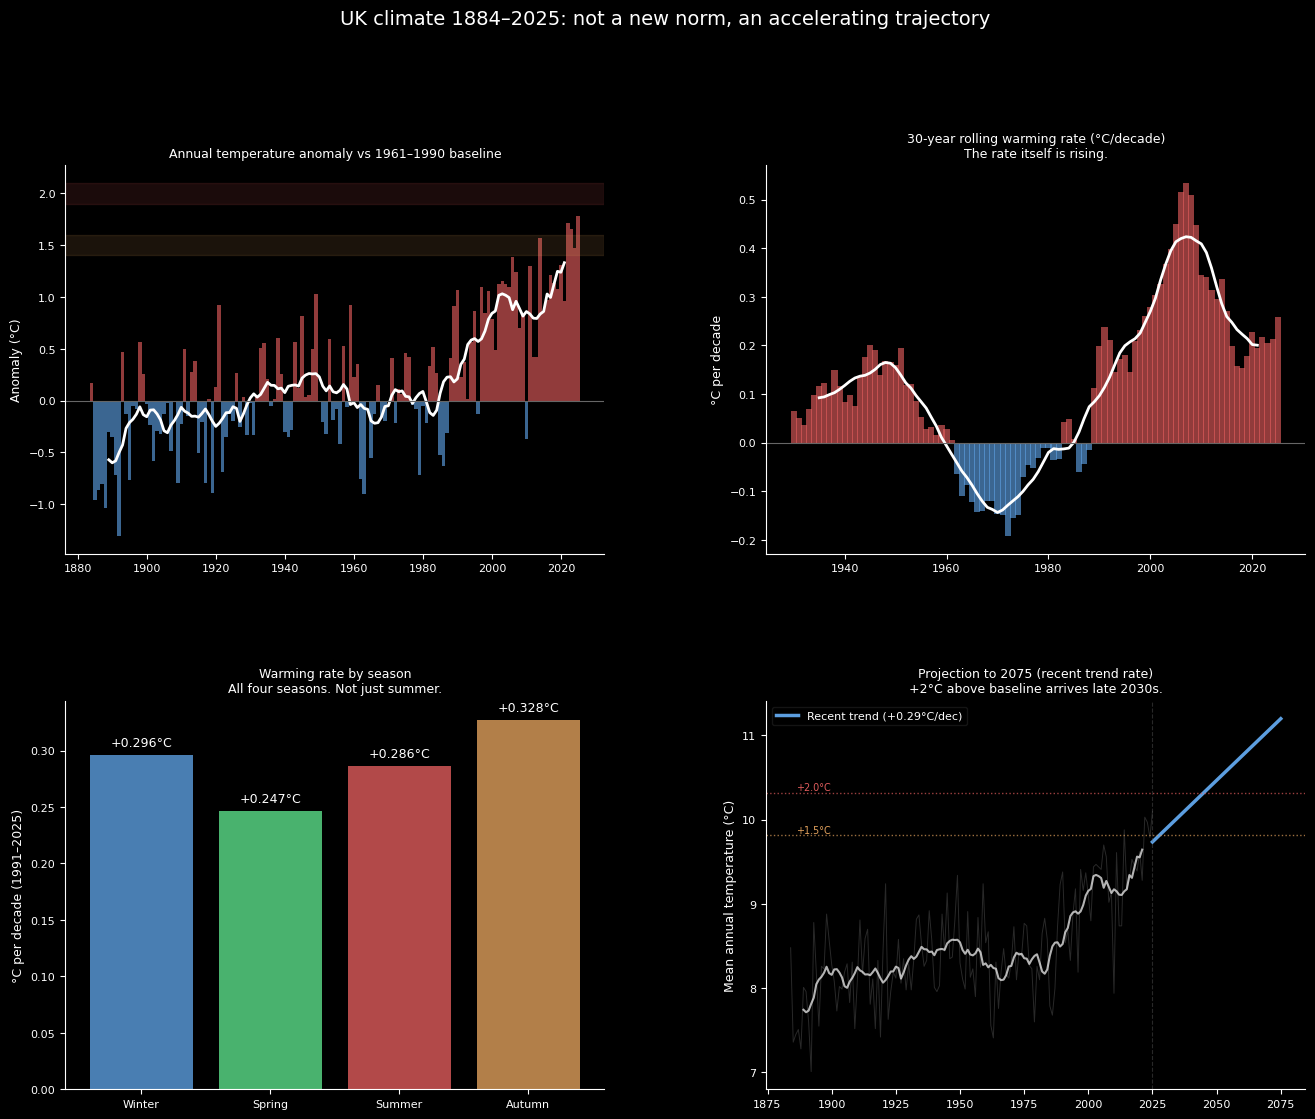

Saved: synthesis.png


In [2]:
fig = plt.figure(figsize=(16, 12))
fig.suptitle('UK climate 1884–2025: not a new norm, an accelerating trajectory',
             fontsize=14, y=1.01)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.3)

# ── Panel 1: Temperature anomaly (top left) ──────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
tmean['anomaly'] = tmean['value'] - baseline
bar_c = [ACCENT if a > 0 else ACCENT2 for a in tmean['anomaly']]
ax1.bar(tmean['year'], tmean['anomaly'], color=bar_c, alpha=0.65, width=1.0, edgecolor='none')
ax1.plot(tmean['year'], tmean['anomaly'].rolling(10, center=True).mean(),
         color='white', linewidth=2)
ax1.axhline(0, color=NEUTRAL, linewidth=0.8)
ax1.axhspan(1.4, 1.6, alpha=0.12, color=AMBER)
ax1.axhspan(1.9, 2.1, alpha=0.12, color=ACCENT)
ax1.set_title('Annual temperature anomaly vs 1961–1990 baseline', fontsize=9)
ax1.set_ylabel('Anomaly (°C)', fontsize=9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.tick_params(labelsize=8)

# ── Panel 2: Rolling 30-year slopes (top right) ───────────────────────────
ax2 = fig.add_subplot(gs[0, 1])

tmean_s = tmean.sort_values('year')
slope_results = []
for end_yr in range(1930, 2026):
    sub = tmean_s[(tmean_s['year'] >= end_yr-29) & (tmean_s['year'] <= end_yr)].dropna(subset=['value'])
    if len(sub) >= 21:
        sl, _, _, _, _ = stats.linregress(sub['year'], sub['value'])
        slope_results.append({'end_year': end_yr, 'slope': sl*10})
slopes_df = pd.DataFrame(slope_results)

if len(slopes_df):
    sc = [ACCENT if s > 0 else ACCENT2 for s in slopes_df['slope']]
    ax2.bar(slopes_df['end_year'], slopes_df['slope'],
            color=sc, alpha=0.65, width=1.2, edgecolor='none')
    ax2.plot(slopes_df['end_year'],
             slopes_df['slope'].rolling(10, center=True).mean(),
             color='white', linewidth=2)
    ax2.axhline(0, color=NEUTRAL, linewidth=0.8)

ax2.set_title('30-year rolling warming rate (°C/decade)\nThe rate itself is rising.', fontsize=9)
ax2.set_ylabel('°C per decade', fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.tick_params(labelsize=8)

# ── Panel 3: Seasonal rates (bottom left) ────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])

SEASON_COLOURS = {'win': ACCENT2, 'spr': GREEN, 'sum': ACCENT, 'aut': AMBER}
SEASON_LABELS  = {'win': 'Winter', 'spr': 'Spring', 'sum': 'Summer', 'aut': 'Autumn'}

seasons_found = []
for season in ['win', 'spr', 'sum', 'aut']:
    s = get_series('Tmean', 'UK', season)
    if len(s) < 20:
        continue
    recent = s[s['year'] >= 1991]
    if len(recent) < 10:
        continue
    slope_rec, _, _, _, _ = stats.linregress(recent['year'], recent['value'])
    seasons_found.append((SEASON_LABELS[season], slope_rec*10, SEASON_COLOURS[season]))

if seasons_found:
    labels_s, rates_s, colours_s = zip(*seasons_found)
    bars = ax3.bar(labels_s, rates_s, color=colours_s, alpha=0.8, edgecolor='none')
    for bar, rate in zip(bars, rates_s):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{rate:+.3f}°C', ha='center', va='bottom', fontsize=9)
else:
    ax3.text(0.5, 0.5, 'Run with full dataset\nfor seasonal breakdown',
             ha='center', va='center', transform=ax3.transAxes,
             color=NEUTRAL, fontsize=10)

ax3.set_ylabel('°C per decade (1991–2025)', fontsize=9)
ax3.set_title('Warming rate by season\nAll four seasons. Not just summer.', fontsize=9)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.tick_params(labelsize=8)

# ── Panel 4: Projection (bottom right) ───────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])

# Historical
ax4.plot(tmean['year'], tmean['value'], color=NEUTRAL, linewidth=0.7, alpha=0.4)
ax4.plot(tmean['year'], tmean['value'].rolling(10, center=True).mean(),
         color='white', linewidth=1.5, alpha=0.7)

# Recent trend projection
rec = tmean[tmean['year'] >= 1991]
slope_p, intercept_p, _, _, _ = stats.linregress(rec['year'], rec['value'])
proj_yrs = np.arange(2025, 2076)
proj_val = slope_p * proj_yrs + intercept_p
ax4.plot(proj_yrs, proj_val, color=ACCENT2, linewidth=2.5,
         label=f'Recent trend ({slope_p*10:+.2f}°C/dec)')

# Threshold lines
for thresh, label, colour in [
    (baseline + 1.5, '+1.5°C', AMBER),
    (baseline + 2.0, '+2.0°C', ACCENT),
]:
    ax4.axhline(thresh, color=colour, linewidth=1, linestyle=':', alpha=0.7)
    ax4.text(1886, thresh + 0.03, label, color=colour, fontsize=7)

ax4.axvline(2025, color=NEUTRAL, linewidth=0.8, linestyle='--', alpha=0.4)
ax4.set_title('Projection to 2075 (recent trend rate)\n'
              '+2°C above baseline arrives late 2030s.', fontsize=9)
ax4.set_ylabel('Mean annual temperature (°C)', fontsize=9)
ax4.legend(fontsize=8, framealpha=0.1)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.tick_params(labelsize=8)

plt.savefig(OUTPUTS / 'synthesis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: synthesis.png')

## What This Analysis Can and Cannot Claim

**What it can claim:** The observed UK climate record, across 141 years of temperature data and nearly 190 years of rainfall, shows an accelerating warming trend, increasing variability, and simultaneous shifts in multiple climate indicators. The rate of warming in the most recent 35 years is nearly three times the full-record average. The trend has not flattened.

**What it cannot claim:** This analysis does not establish cause. The attribution question — how much of the observed change is human-caused versus natural variability — requires climate modelling beyond the scope of this work. The projections are extrapolations of observed trend, not outputs of a physical climate model. They should be read as *what the current trajectory implies*, not as forecasts.

**What the wider science says:** The attribution question has been answered elsewhere, comprehensively, by the IPCC and the Met Office's own UKCP18 projections. The observed changes in the UK record are consistent with those assessments. This analysis contributes an independently reproducible view of the observed record — grounded in public data, transparent methodology, and explicit uncertainty — that anyone can verify and extend.

In [3]:
# Final summary statistics — the numbers that matter
print('=== Summary Statistics ===')
print()

s_full = stats.linregress(tmean['year'], tmean['value'])
s_rec  = stats.linregress(rec['year'], rec['value'])

above_baseline    = (tmean['anomaly'] > 0).sum()
above_15          = (tmean['value'] >= baseline + 1.5).sum()
post2000_top15    = (tmean.nlargest(15, 'value')['year'] >= 2000).sum()

early_std  = tmean[tmean['year'].between(1884,1913)]['value'].std()
recent_std = tmean[tmean['year'].between(2006,2025)]['value'].std()

thresh_20_year = (baseline + 2.0 - s_rec[1]) / s_rec[0]

print(f'Record length:                    {len(tmean)} years ({tmean["year"].min()}–{tmean["year"].max()})')
print(f'1961–1990 baseline mean:          {baseline:.3f}°C')
print(f'Full-record warming rate:         {s_full[0]*10:+.4f}°C/decade')
print(f'Recent warming rate (1991–2025):  {s_rec[0]*10:+.4f}°C/decade')
print(f'Acceleration factor:              {s_rec[0]/s_full[0]:.1f}×')
print(f'Years above baseline mean:        {above_baseline} of {len(tmean)}')
print(f'Years ≥+1.5°C above baseline:     {above_15}')
print(f'Top 15 warmest since 2000:        {post2000_top15} of 15')
print(f'Variability change:               {early_std:.3f}°C → {recent_std:.3f}°C std ({(recent_std/early_std-1)*100:.0f}% increase)')
print(f'+2°C threshold crossing year:     ~{thresh_20_year:.0f} (trend line, recent rate)')

=== Summary Statistics ===

Record length:                    142 years (1884–2025)
1961–1990 baseline mean:          8.315°C
Full-record warming rate:         +0.1027°C/decade
Recent warming rate (1991–2025):  +0.2925°C/decade
Acceleration factor:              2.8×
Years above baseline mean:        76 of 142
Years ≥+1.5°C above baseline:     4
Top 15 warmest since 2000:        14 of 15
Variability change:               0.475°C → 0.519°C std (9% increase)
+2°C threshold crossing year:     ~2045 (trend line, recent rate)


## A Note on the Question This Analysis Leaves Open

The question of what happens if this trajectory continues is ultimately not a data question. The data describes what has happened and what the current rate implies. Whether that rate is reduced — and by how much, and how quickly — is a question for emissions policy, international agreements, and technological change.

What the data does is remove the comfort of ambiguity. The warming is real, measurable, accelerating, and consistent across every indicator we can observe. The argument that we have simply shifted to a new, stable, warmer climate is not supported by any of the evidence examined here. The slope has not flattened. The variability has not reduced. The records keep falling.

The new norm framing is not just wrong — it is actively dangerous, because it suggests adaptation is sufficient when the evidence points toward a trajectory that adaptation alone cannot address.

---

*Analysis based on Met Office HadUK-Grid regional climate series. All data publicly available at https://www.metoffice.gov.uk/research/climate/maps-and-data/uk-and-regional-series. Full methodology and reproducible code at https://github.com/stetho/uk-climate-analysis.*